# Deep Learning 101

## 1. Setting up the deep learning work station

###### Run the following commands in command line interface

```
#------------------
#creating an environment dedicated to deep learning.
#------------------

conda create -n deeplearning python=3.10
conda activate deeplearning

#------------------
#INSTALL PYTORCH: https://pytorch.org/
#------------------
#MACOS USE:
conda install pytorch torchvision torchaudio -c pytorch

#LINUX USE:
conda install pytorch torchvision torchaudio cpuonly -c pytorch

#WINDOWS USE:
conda install pytorch torchvision torchaudio cpuonly -c pytorch


#------------------
#INSTALL TENSORFLOW: 
#------------------

#INTEL MAC AND WINDOWS USERS 
python -m pip install --upgrade pip
python -m pip install tensorflow


#MAC M1 USERS 
conda install -c apple tensorflow-deps -y
python -m pip install --upgrade pip
python -m pip install tensorflow-macos
python -m pip install tensorflow-metal
#for more details see the following video
#https://www.youtube.com/watch?v=4nY5lDBXdOg&t=88s (Links to an external site.)

#------------------
# ADDITIONAL PACKAGES
#------------------
conda install scipy
conda install -c conda-forge matplotlib
conda install -c anaconda pandas
conda install ipykernel --update-deps --force-reinstall

```

## 2. Check the setup

In [3]:
import torch
x = torch.rand(5, 3)
print(x, type(x))

tensor([[0.6493, 0.7584, 0.7870],
        [0.9953, 0.7599, 0.5160],
        [0.5629, 0.5866, 0.8933],
        [0.9720, 0.7840, 0.8770],
        [0.9440, 0.8334, 0.6205]]) <class 'torch.Tensor'>


In [4]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers

model = keras.Sequential([layers.Dense(1,activation='sigmoid',input_shape=(1,)),])

print(model.summary()); 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


## 3. Python Basics

### I. Python Objects and Classes

* **Classes are "blue prints" or "templates" for building customizable data-structures**
  *  Think of them as "customizable" boxes that can;
     *  (1) store **data** in what are known as "**attributes** of the class" 
         * These are comparable to how Dictionaries have keys and values
     *  (2) preform actions on themselves using **functions** which are known as "**methods** of the class".
  *  For example, if you wanted to build a custom data-structure to describe "animals" for a biology project.
     *  Then you could create a python class called "animal" to store information about the different animals in the study. 
     *  This class would be a "**template**" for define objects (see below) of the class "animal", for example
        * **Attributes** of class "animal"
           *  name
           *  species
        * **Methods** of class animal 
           * update_name(new_name) --> name=new_name  
           * i.e. change the animal's name with this method   
  <br />
     * **IN SUMMARY: CLASSES ARE "EMPTY TEMPLATES" FOR DEFINING OBJECTS** 
<br /><br />
*  **Objects are a particular instance of a class (i.e. a **populated template** of that class)**
   *  For example;
      * object_1: the first instance of class "animal"
         * object_1 attributes 
           * name="luna"
           * species="dog"
       * object_2: the second instance of class "animal"
         * object_2 attributes 
           * name="jack"
           * species="cat"
      * You can think of the "attributes" as metadata associated with the various objects
      * Also **both objects** would have access to the "update_name" method, which could be used at any time to change their name.
  <br /><br />
       * **IN SUMMARY: OBJECTS ARE "POPULATED TEMPLATES" (INSTANCES) OF A PARTICULAR CLASS** 
<br /><br />
* **In python attributes and methods of an object are accessed using "." at the end**
  * In the case of the previous example;
    * print(object_1.name) --> "luna"
    * print(object_1.species) --> "dog"
    * object_1.update_name("stinky")
    * print(object_1.name) --> "stinky"



In [11]:
#FOR MORE: https://docs.python.org/3/tutorial/classes.html

#REMEMBER 
#AND OBJECT IS A SPECIFIC INSTANCE OF A CLASS
#THE CLASS ITSELF IS A TEMPLATE FOR OBJECTS 
class Dog:

    # class variable shared by all instances
    kind = 'canine'        

    #INITIALIZE
    def __init__(self, attributions):
        self.name = attributions[0]      # instance variable unique to each instance
        self.weight = attributions[1]    
        self.possesions=[]               #initial as empty, fill later

    def increase_weight(self,dw=1):
    	self.weight+=dw


#INITIALIZE TWO OBJECTS OF CLASS DOG
L = Dog(['Luna' ,40])
S = Dog(['Spark',50])


#SEE INITIAL ATTRIBUTES
print("#-----------------------")
print(L.name, L.weight, L.kind)
print(S.name, S.weight, S.kind)

#RUN THE increase_weight() METHOD
print("#-----------------------")
L.increase_weight()
print(L.name, L.weight, L.kind)
L.increase_weight(5)
print(L.name, L.weight, L.kind)


#POPULATE POSSSESSION
print("#-----------------------")
print(S.name, S.weight, S.kind,S.possesions)
S.possesions=['collar','leash','bowl']
print(S.name, S.weight, S.kind,S.possesions)
S.possesions.append('dog food')
print(S.name, S.weight, S.kind,S.possesions)


#SUBCLASS
    #NOTICE IT INHERITS ATTRIBUTIONS OF CLASS Dog
class SmallDog(Dog):
    size="small"
    
    # provides new attributions 
    # but does not break __init__()
    def update(self, H):
        self.height=H

B = SmallDog(['Bo' ,15])
B.update(1)
print(B.name, B.weight, B.kind, B.possesions,B.size,"H=",B.height)

#-----------------------
Luna 40 canine
Spark 50 canine
#-----------------------
Luna 41 canine
Luna 46 canine
#-----------------------
Spark 50 canine []
Spark 50 canine ['collar', 'leash', 'bowl']
Spark 50 canine ['collar', 'leash', 'bowl', 'dog food']
Bo 15 canine [] small H= 1


**Let's**:
* Create a class called linear_algebra 
* use floats and python lists to store class objects as floats, vectors, and matrices
* provide an attribute for the objects of the class call .type = scalar, vector, matrix (don't need to do higher rank tensors)
* provide an attribute.shape which returns the shape of the vector 
* make a class method flatten() which acts on matrices and converts them into vector (lists)

In [12]:
import numpy as np 

## Class initialization 
class linear_algebra :

     
    def __init__(self, val):
        ## user given input value that needs to be checked
        input_type = str(type(val))  
        
        ## checking if the input is a Scalar , Vector or Matrix 
        ##if its a float or int then store it in scalar
        if(input_type == "<class 'float'>" or input_type == "<class 'int'>"):
            self.type = 'Scalar'        #instance variables - these are unique to each instance
            self.value = val
            self.shape = ()
            
        ##its a vector if the class is list and has a length of 1
        elif(input_type == "<class 'list'>" and len(np.shape(val)) == 1):
            self.type = 'Vector'
            self.value = val
            self.shape = np.shape(val)
        else :
            self.type = 'Matrix'
            self.value = val
            self.shape = np.shape(val) 

    def flatten(self,type, value):

        ## Check if the type is Matrix or not
        if(type == 'Matrix'):
            self.value = np.array(value).flatten()
            self.type = 'Vector'
            self.shape = np.shape(np.array(value).flatten())
        else :
            print("The given input isn't a matrix")

In [13]:
## objects of the linear_algebra class.
## Checks 
##scalar
scalar = linear_algebra(20.00)
print(scalar.type)
print(scalar.shape)

Scalar
()


In [14]:
## vector
vect = linear_algebra([2,4])
print(vect.type)
print(vect.shape)


Vector
(2,)


In [15]:
## matrix
A = linear_algebra([[4,5],[6,7]])
print(A.type)
print(A.shape)

Matrix
(2, 2)


In [20]:
##flatten method 
A.flatten(A.type, A.value)
print(A.type)
print(A.shape)
print(A.value)


Vector
(4,)
[4 5 6 7]


### II. Numpy Basics

In [22]:
import numpy as np
from pandas import DataFrame
import time

#QUICK INFO ON NP ARRAY
def np_array_info(X,MESSAGE='SUMMARY'):
    print("\n------------------------")
    print(MESSAGE)
    print("------------------------")
    print("TYPE:",type(X))

    if(str(type(x))=="<class 'numpy.ndarray'>"):

        print("SHAPE:",X.shape)
        print("MIN:",X.min())
        print("MAX:",X.max())
        #NOTE: ADD SLICEING
        print("DTYPE:",X.dtype)
        print("NDIM:",X.ndim)
        print("IS CONTIGUOUS:",X.data.contiguous)
        #PRETTY PRINT 
        if(X.ndim==1 or X.ndim==2 ): 
            print("MATRIX:")
            print(DataFrame(X).to_string(index=False, header=False))
            # print("EDGES ARE INDICES: i=row,j=col") 
            # print(DataFrame(X)) 	
    else:
        print("ERROR: INPUT IS NOT A NUMPY ARRAY")

#### 1. Basic Data Types

In [23]:
#SCALAR (0D TENSOR)
x = np.array(10); 
np_array_info(x)


------------------------
SUMMARY
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: ()
MIN: 10
MAX: 10
DTYPE: int32
NDIM: 0
IS CONTIGUOUS: True


In [24]:
#VECTOR AS 1D ARRARY
x = np.array([12, 3, 6, 14]); 
np_array_info(x)


------------------------
SUMMARY
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (4,)
MIN: 3
MAX: 14
DTYPE: int32
NDIM: 1
IS CONTIGUOUS: True
MATRIX:
12
 3
 6
14


In [25]:
#VECTOR AS 2D ARRAY 
x = np.array([12, 3, 6, 14]);  
x=x.reshape(len(x),1); 
np_array_info(x) #COLUMN VECTOR


------------------------
SUMMARY
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (4, 1)
MIN: 3
MAX: 14
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
12
 3
 6
14


In [26]:
x = np.array([12, 3., 6, 14]); 
x=x.reshape(1,len(x)); 
np_array_info(x) #ROW VECTOR


------------------------
SUMMARY
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (1, 4)
MIN: 3.0
MAX: 14.0
DTYPE: float64
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
12.0 3.0 6.0 14.0


In [27]:
#MATRIX (2D TENSOR)
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]]); 
np_array_info(x)


------------------------
SUMMARY
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (3, 5)
MIN: 0
MAX: 80
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
5 78 2 34 0
6 79 3 35 1
7 80 4 36 2


In [28]:
# #3D TENSOR
x = np.array([[[5., 78, 2, 34, 0],
			   [6, 79, 3, 35, 1],
			   [7, 80, 4, 36, 2]],
			  [[5, 78, 2, 34, 0],
			   [6, 79, 3, 35, 1],
			   [7, 80, 4, 36, 2]],
			  [[5, 78, 2, 34, 0],
			   [6, 79, 3, 35, 1],
			   [7, 80, 4, 36, 2]]]) ; 
np_array_info(x,"3D TENSOR")


------------------------
3D TENSOR
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (3, 3, 5)
MIN: 0.0
MAX: 80.0
DTYPE: float64
NDIM: 3
IS CONTIGUOUS: True


#### 2. TRANSPOSE AND RESHAPE

In [29]:
x = np.array([[11, 12, 13],
            [21, 22, 23]]); 
np_array_info(x, "BEFORE TRANSPOSE")
np_array_info(np.transpose(x), "AFTER  TRANSPOSE")


------------------------
BEFORE TRANSPOSE
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (2, 3)
MIN: 11
MAX: 23
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
11 12 13
21 22 23

------------------------
AFTER  TRANSPOSE
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (3, 2)
MIN: 11
MAX: 23
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
11 21
12 22
13 23


In [30]:
#RESHAPING 
x = np.array([[11, 12, 13, 14],
              [21, 22, 23, 24],
              [31, 32, 33, 34],
              [41, 42, 43, 44], 
              [51, 52, 53, 54]]); 
            
np_array_info(x.reshape(x.shape[0]*x.shape[1],1), "x.reshape(x.shape[0]*x.shape[1],1)")
np_array_info(x.reshape(1,x.shape[0]*x.shape[1]), "x.reshape(1,x.shape[0]*x.shape[1])")
np_array_info(x.reshape(int(x.shape[0]*x.shape[1]/2),2), "x.reshape(int(x.shape[0]*x.shape[1]/2),2)")


------------------------
x.reshape(x.shape[0]*x.shape[1],1)
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (20, 1)
MIN: 11
MAX: 54
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
11
12
13
14
21
22
23
24
31
32
33
34
41
42
43
44
51
52
53
54

------------------------
x.reshape(1,x.shape[0]*x.shape[1])
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (1, 20)
MIN: 11
MAX: 54
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
11 12 13 14 21 22 23 24 31 32 33 34 41 42 43 44 51 52 53 54

------------------------
x.reshape(int(x.shape[0]*x.shape[1]/2),2)
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (10, 2)
MIN: 11
MAX: 54
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
11 12
13 14
21 22
23 24
31 32
33 34
41 42
43 44
51 52
53 54


#### 3. SLICING

In [31]:
x = np.array([[11, 12, 13, 14],
              [21, 22, 23, 24],
              [31, 32, 33, 34],
              [41, 42, 43, 44], 
              [51, 52, 53, 54]]); 

In [32]:
np_array_info(x, "BEFORE SLICING")


------------------------
BEFORE SLICING
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (5, 4)
MIN: 11
MAX: 54
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
11 12 13 14
21 22 23 24
31 32 33 34
41 42 43 44
51 52 53 54


In [33]:
#NOTICE HOW ITS INCLUSIVE ON THE LEFT
#AND EXCLUSIVE ON THE RIGHT
np_array_info(x[:,1], 	 "SLICE-1: x[:,1]")
np_array_info(x[2,:], 	"SLICE-2: x[2,:]")
np_array_info(x[1:3], 	"SLICE-3: x[1:3]")
np_array_info(x[:,-3:-1],"SLICE-4: x[:,-3:-1]")
np_array_info(x[:,0:2], 	"SLICE-5: x[:,0:2]")


------------------------
SLICE-1: x[:,1]
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (5,)
MIN: 12
MAX: 52
DTYPE: int32
NDIM: 1
IS CONTIGUOUS: False
MATRIX:
12
22
32
42
52

------------------------
SLICE-2: x[2,:]
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (4,)
MIN: 31
MAX: 34
DTYPE: int32
NDIM: 1
IS CONTIGUOUS: True
MATRIX:
31
32
33
34

------------------------
SLICE-3: x[1:3]
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (2, 4)
MIN: 21
MAX: 34
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
21 22 23 24
31 32 33 34

------------------------
SLICE-4: x[:,-3:-1]
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (5, 2)
MIN: 12
MAX: 53
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: False
MATRIX:
12 13
22 23
32 33
42 43
52 53

------------------------
SLICE-5: x[:,0:2]
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (5, 2)
MIN: 11
MAX: 52
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: False
MATRIX:
11 12
21 22
31 32
41 42
51 52


#### 4. BROADCAST

In [34]:
np_array_info(x,        "BEFORE BROADCAST")
np_array_info(x+1000,   "ADD 1000 TO ALL")
np_array_info(x+x[0,:], "ADD FIRST ROW TO EACH ROW")


------------------------
BEFORE BROADCAST
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (5, 4)
MIN: 11
MAX: 54
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
11 12 13 14
21 22 23 24
31 32 33 34
41 42 43 44
51 52 53 54

------------------------
ADD 1000 TO ALL
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (5, 4)
MIN: 1011
MAX: 1054
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
1011 1012 1013 1014
1021 1022 1023 1024
1031 1032 1033 1034
1041 1042 1043 1044
1051 1052 1053 1054

------------------------
ADD FIRST ROW TO EACH ROW
------------------------
TYPE: <class 'numpy.ndarray'>
SHAPE: (5, 4)
MIN: 22
MAX: 68
DTYPE: int32
NDIM: 2
IS CONTIGUOUS: True
MATRIX:
22 24 26 28
32 34 36 38
42 44 46 48
52 54 56 58
62 64 66 68


## 4. The universal machine learning workflow

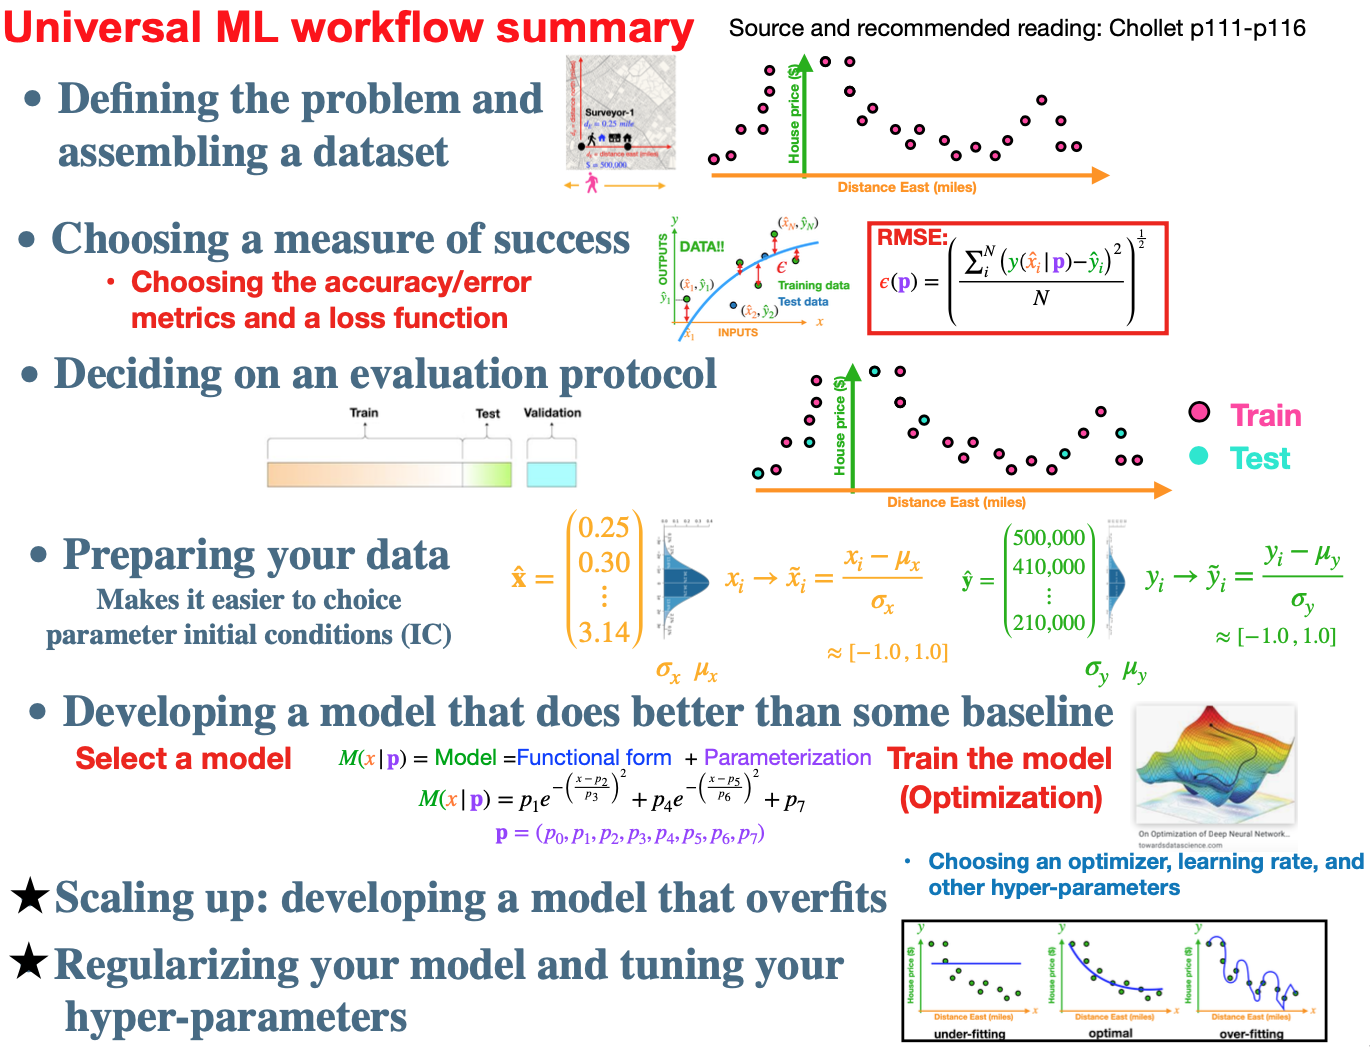

In [37]:
from IPython.display import Image
Image(filename="C:\\Users\\mprak\\OneDrive\\Desktop\\ml workflow.png", width=600)

#### I. Import the packages

In [38]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from   scipy.optimize import curve_fit

#### II. Define "toy" dataset

In [40]:
#GROUND TRUTH FUNCTION
def G(x):
    out=400000.0*np.exp(-((x-0.0)/2.0)**2.0)
    out=out+150000.0*np.exp(-((x-15.0)/1.5)**2.0)
    out=out+100000

    return out

In [41]:
#NOISY DATA
N=100; xmin=-10; xmax=20
x = np.linspace(xmin,xmax,N)
ye = G(x)  #PRISTINE DATA
#noise=np.random.normal(loc=0.0, scale=0.05*(max(y)-min(y)),size=len(x))
noise=0.05*(max(ye)-min(ye))*np.random.uniform(-1,1,size=len(x))
y = ye + noise

x = x.reshape(N,1)
y = y.reshape(N,1)
print(x.shape,ye.shape)

(100, 1) (100,)


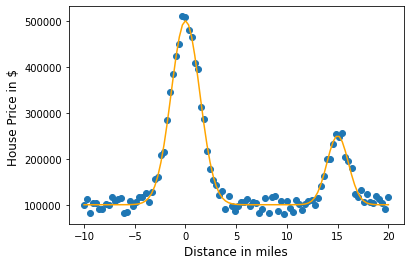

In [42]:
plt.figure()

plt.xlabel('Distance in miles', fontsize=12)
plt.ylabel('House Price in $ ', fontsize=12)

#ground truth plot
plt.plot(x,ye, color = "orange")

#data plot
plt.scatter(x,y)

#### III. Define a measure of success
Let's use the root mean square error for a measure of success.
RMSE is one of the most common regression objective function (i.e error metric).

In [43]:
def loss(p):
    global x_train, y_train
    #INSERT CODE HERE

    #Using function m from part 4
    y_pred = m(x_train,p)
    
    #rmse 
    n=y_pred - y_train
    sq_error = pow(n,2)
    sum_sq_error = np.sum(sq_error)
    rmse = np.sqrt(sum_sq_error / len(y_train))  
    
    return(rmse) 

#### IV. Define Evaluation protocol  

In this section,  
1. We split the data into an 80-20 training-validation set.  
2. Plot the training and validation data together. 

In [44]:
from sklearn.model_selection import train_test_split

#splitting the data using sklearn
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

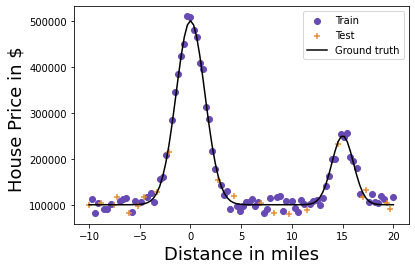

In [45]:
#Plotting the data
plt.figure()
FS=18   #FONT SIZE
plt.xlabel('Distance in miles', fontsize=FS)
plt.ylabel('House Price in $ ', fontsize=FS)

#train data
plt.scatter(x_train,y_train, color = "#674AB3", label = "Train")

#test data 
plt.scatter(x_test,y_test, color = "#E68E36", label = "Test", marker = "+")

#ground truth
plt.plot(x,ye, color = "black", label = "Ground truth")

#legend
plt.legend()

#### V. Prepare the data

Let's 
1. Normalize the x data using x --> (x-u_x)/sigma_x
2. Normalize the y data using y --> (y-u_y)/sigma_y
3. The quantities u_x, u_y, sigma_x and sigma_y should be stored as variables and computed from the training set
4. Re-plot the data, notice how numbers on the axis are dramatically different and range roughly -2 to 2.


In [46]:
#Finding the mean and standard deviation of x and normalizing train x 
u_x = np.mean(x_train)
sigma_x = np.std(x_train)
x_train = (x_train - u_x)/sigma_x

#Finding the mean and standard deviation of y and normalizing train y 
u_y = np.mean(y_train)
sigma_y = np.std(y_train)
y_train = (y_train - u_y)/sigma_y

#Normalizing the testing set
x_test = (x_test - u_x)/sigma_x
y_test = (y_test - u_y)/sigma_y 

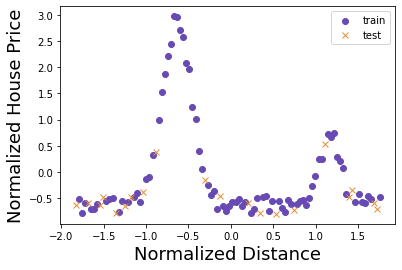

In [47]:
plt.figure() #INITIALIZE FIGURE 
FS=18   #FONT SIZE
plt.xlabel('Normalized Distance', fontsize=FS)
plt.ylabel('Normalized House Price', fontsize=FS)

#Plotting the data
plt.scatter(x_train,y_train, label = 'train', color='#674AB3')
plt.plot(x_test,y_test,'x', label = 'test', color='#E68E36')
plt.legend()

#### VI. Choose a model

In this section, we:

1. Write a function m(x,p) which takes a vector of data x, and a parameter vector p, and evaluates the model
2. Use the parametric fitting model using the double Gaussian from lecture-1 as your model

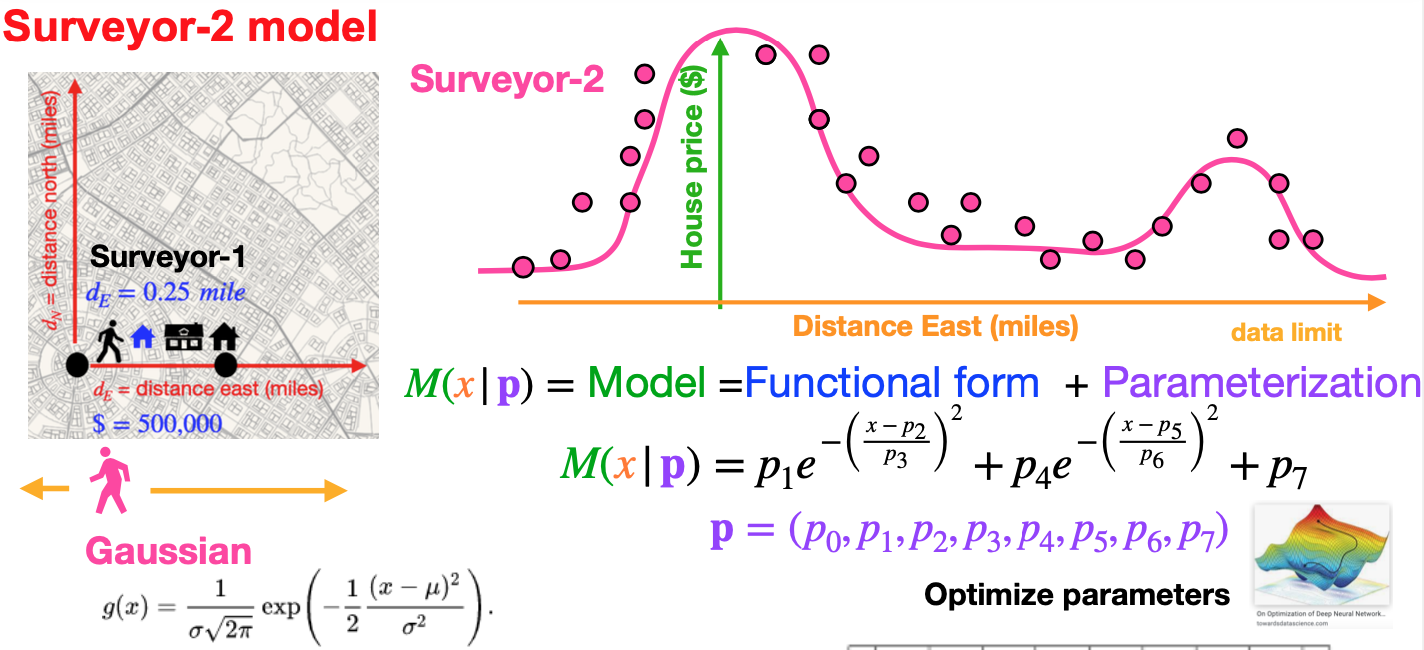

In [49]:
Image(filename= "C:\\Users\\mprak\\OneDrive\\Desktop\\download.png", width=500)


In [50]:
def m(x,p):
# parametric fitting model
    return(p[0]*np.exp(-(((x-p[1])/p[2])**2)) +  p[3]*np.exp(-((x-p[4])/p[5])**2) + p[6])

#### VII. Train your model

1. Choose an initial guess for the parameter vector p. If the initial guess is randomly generated, then run the optimization algorithm several times before getting a good fit.  
2. Note that "bad fits", correspond to bad choices for the fitting parameters, these occur when the optimizer gets "stuck" in a bad local minima in the parameter space.  
3. Optionally, you can ensure a "good fit" every time, by looking at the normalized plot and the functional form of the model and manually choosing fitting parameters that "make sense".  
4. Use the Scipy minimizer from Part-1 to minimize the loss function, by varying the components of the parameter vector p, to find the best fit for the model.  
5. Make predictions with the fitted model for the test and validation data.  
6. plot the predictions in the normalized space. 
7. un-normalize the data so that it has units again.  
8. Plot the results in the un-normalized space.  

In [52]:
#Randomly generate the initial guess 
from   scipy.optimize import minimize

param_v = np.array([3,-0.5,0.5,1,1.25,0.5,-0.5])

#Run the optimizer with a parametric vector v

print("Initial guess:\n",param_v,"\n")

result = minimize(loss, param_v, method='BFGS', tol=1e-5)

#Updated guess
print("Updated Guess:\n",result.x,"\n")

#Current loss
print("Current Loss:\n",result.fun,"\n")

Initial guess:
 [ 3.   -0.5   0.5   1.    1.25  0.5  -0.5 ] 

Updated Guess:
 [ 3.49402055 -0.63835923  0.24041258  1.33480645  1.16478952  0.16688618
 -0.60579091] 

Current Loss:
 0.10017657495032609 



In [53]:
p_train = m(x_train,result.x)
p_test = m(x_test,result.x)

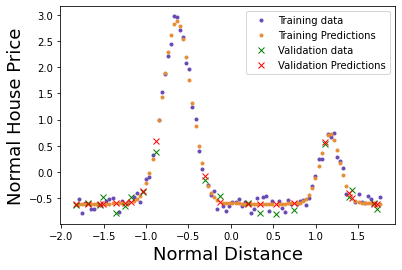

In [54]:
plt.figure() #INITIALIZE FIGURE 
FS=18   #FONT SIZE

plt.xlabel('Normal Distance', fontsize=FS)
plt.ylabel('Normal House Price', fontsize=FS)

plt.plot(x_train,y_train, '.', label = 'Training data',color="#674AB3")
plt.plot(x_train,p_train,'.', label = 'Training Predictions', color="#E68E36")
plt.plot(x_test,y_test,'x', label = 'Validation data', color="green")
plt.plot(x_test,p_test,'x', label = 'Validation Predictions', color="red")
plt.legend()

In [57]:
#un-normalize training
x_train = (x_train * sigma_x ) + u_x
y_train = (y_train * sigma_y ) + u_y

#un-normalize test
x_test = (x_test * sigma_x ) + u_x
y_test = (y_test * sigma_y ) + u_y

#un-normalize prediction
p_train = (p_train * sigma_y) + u_y
p_test = (p_test * sigma_y) + u_y# UN-NORMALIZE THE DATA

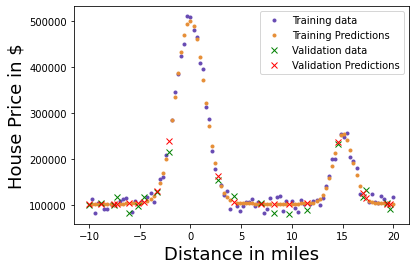

In [56]:
#PLOT THE RESULTS IN THE UN-NORMALIZED SPACE


plt.figure() #INITIALIZE FIGURE 
FS=18   #FONT SIZE

plt.xlabel('Distance in miles', fontsize=FS)
plt.ylabel('House Price in $', fontsize=FS)

plt.plot(x_train,y_train, '.',  label = 'Training data',color="#674AB3")
plt.plot(x_train,p_train,'.', label = 'Training Predictions', color="#E68E36")
plt.plot(x_test,y_test,'x', label = 'Validation data', color="green")
plt.plot(x_test,p_test,'x', label = 'Validation Predictions', color="red")
plt.legend()

## 5. Generaliziation for multi-variable linear regression

#### I. Import the packages

In [58]:
import numpy as np
import matplotlib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from   scipy.optimize import minimize
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from   scipy.optimize import minimize
import pandas as pd
import seaborn as sns

In [59]:
# EVALUATE THE SIGMOID (LOGISTIC) FUNCTION COMPONENT WISE ON A NUMPY ARRAY
def s(x):
    return 1/(1 + np.exp(-x))

#### II. Define the dataset

In [60]:
dataset="2D_LINEAR"; model_type="linear"
#dataset="2D_LOGISTIC"; model_type="logistic"
#dataset="5D_LINEAR"; model_type="linear"

# DATA PARAM
N=2000; 
xmin=-10; 
xmax=10

if(dataset=="2D_LINEAR" or dataset=="2D_LOGISTIC"):
    #DEFINE A RANDOM INPUT MATRIX (X) ITH TWO FEATURES
    x=np.random.uniform(-10,10,(N,2))
    #DEFINE RESPONSE VARIABLES Y USING A LINEAR RESPONSE
    noise=np.random.uniform(-0.5,0.5,(N,))
    y=1.4*x[:,0]+4.5*x[:,1]+5+noise
    y=y.reshape(N,1)
    if(dataset=="2D_LOGISTIC"):
        y=s(y)
if(dataset=="5D_LINEAR"):
    #DEFINE A RANDOM INPUT MATRIX (X) ITH TWO FEATURES
    x=np.random.uniform(-10,10,(N,5))
    #DEFINE RESPONSE VARIABLES Y USING A LINEAR RESPONSE
    noise=np.random.uniform(-0.5,0.5,(N,))
    y=1.4*x[:,0]+4.5*x[:,1]+3.5*x[:,2]+8.6*x[:,3]-1.5*x[:,4]+5+noise
    y=y.reshape(N,1)

#### III. Explore the data

In [61]:
#PRINT THE SHAPE OF YOUR DATA SET
print("shape of x: ", x.shape)
print("shape of y: ", y.shape)

shape of x:  (2000, 2)
shape of y:  (2000, 1)


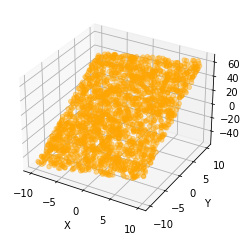

In [62]:
#PLOT IN 3D (XYZ) IF x.shape[1]=2 (otherwise do nothing)

if(x.shape[1]==2):
    
    fig = plt.figure()
 
    
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plot_df = pd.DataFrame(x)
    plot_df['y'] = y
    ax.scatter(x[:,0].reshape(N,1), x[:,1].reshape(N,1),y, alpha = 0.4, color = 'orange')
else:
    print("not valid number of columns")

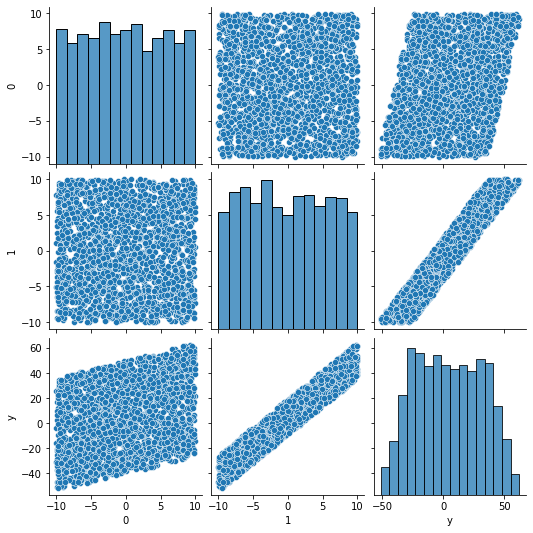

In [63]:
## PAIR-CORRLATION PLOT WITH SEABORN FOR THE X and Y DATA

df=pd.DataFrame(x)


df["y"] = y

sns.pairplot(df)

##### Define the model

In [64]:
#TAKES A MATRIX X, A VECTOR P, AND RETURNS EITHER A LINEAR OR LOGISTIC MODEL
# * it should work for linear regression and logistic regression
# * in both cases use p[0] as the bias term

def m(x,p):
    p=p.reshape(p.shape[0],1)
    
    if (model_type=="linear"):
        return  p[0]+np.matmul(x,p[1:])
    elif (model_type=="logistic"):
        return  s(p[0]+np.matmul(x,p[1:]))
    #FINISH

#### IV. Define a measure of success

Let's continue using RMSE

In [65]:
#  * Write an objective function, called "loss", that returns the RMSE for the training set, given a parameterization vector p for a model (see below for more on the model) 
#   * This can be done in one line with Numpy component wise operations or with a for loop to compute the sum

def loss(p):
    #INSERT CODE HERE
    y_pred = m(x_train,p)
    
    #rmse 
    n=y_pred - y_train
    sq_error = pow(n,2)
    sum_sq_error = np.sum(sq_error)
    rmse = np.sqrt(sum_sq_error / len(y_train))  
    
    return(rmse)
 

#### V. Define Evaluation protocol

Let's
1. Split the data into an 80-20 training-validation set
2. Plot the training and validation data together

In [66]:
#PARTITION DATA

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2) ## Splitting the data 

In [67]:
#PRINT THE SHAPE OF THE TRAINING SET (SANITY CHECK)
print("shape of X train: ", x_train.shape)
print("shape of Y train: ", y_train.shape)

shape of X train:  (1600, 2)
shape of Y train:  (1600, 1)


In [68]:
#PRINT THE SHAPE OF THE VALIDATION SET (SANITY CHECK)
print("shape of X Test : ", x_test.shape)
print("shape of Y Test : ", y_test.shape)

shape of X Test :  (400, 2)
shape of Y Test :  (400, 1)


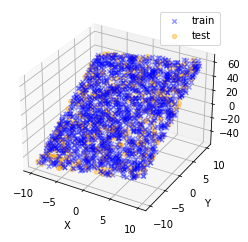

In [69]:
# PLOT IN 3D BOTH THE THE TRAINING AND VALIDATION SET ONLY IF x.shape[1]=2 (otherwise do nothing)

if(x_train.shape[1]==2):
    
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    train_df = pd.DataFrame(x_train)
    test_df = pd.DataFrame(x_test)

    ax.scatter(train_df[0], train_df[1],y_train, color = 'blue', alpha = 0.4 ,label = "train", marker = 'x')

    ax.scatter(test_df[0], test_df[1],y_test, color = 'orange', alpha = 0.4 ,label = "test")

    plt.legend(loc="upper right")
 
    plt.show()
    
else :
    print("not valid number of columns")

#### V. Data Preparation


In this section:
1. Normalize the x data using x --> (x-u_x)/sigma_x
2. Normalize the y data using y --> (y-u_y)/sigma_y
3. The quantities u_x, u_y, sigma_x and sigma_y should be stored as variables and computed from the training set
4. Re-plot the data, notice how numbers on the axis are dramatically different and range roughly -2 to 2.


In [70]:
#COMPUTE THE MEAN DOWN THE COLUMNS OF X AND Y 

#Finding the mean and standard deviation to carry out normalization
#normalizing train x 
u_x = np.mean(x_train)
sigma_x = np.std(x_train)
x_train = (x_train - u_x)/sigma_x
#normalizing train y 
u_y = np.mean(y_train)
sigma_y = np.std(y_train)
y_train = (y_train - u_y)/sigma_y
#Normalizing the testing set
x_test = (x_test - u_x)/sigma_x
y_test = (y_test - u_y)/sigma_y

In [71]:
# PRINT THE MEAN, STD, AND THE SHAPES (SANITY CHECK)

print("The mean of the X_train is: ",u_x,  "std of the X_train is: ", sigma_x)
print("The mean of the Y_train is: ",u_y, "std of the Y_train is: ", sigma_y)
print("The shape of x_train and x_test is: ", x_train.shape, " and ", x_test.shape)
print("The shape of y_train and y_test is: ", y_train.shape, " and ", y_test.shape)

The mean of the X_train is:  -0.020443452693092102 std of the X_train is:  5.710658729743568
The mean of the Y_train is:  4.9081750693807376 std of the Y_train is:  26.787100812801732
The shape of x_train and x_test is:  (1600, 2)  and  (400, 2)
The shape of y_train and y_test is:  (1600, 1)  and  (400, 1)


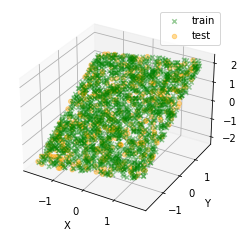

In [72]:
#PLOT IN 3D BOTH THE THE TRAINING AND VALIDATION SET ONLY IF x.shape[1]=2 (otherwise do nothing)

if(x_train.shape[1]==2):
    
    fig = plt.figure()
 
   
    ax = fig.add_subplot(projection='3d')

    ax.set_xlabel('X')
  
    ax.set_ylabel('Y')
    
    ax.set_zlabel('Z')

    train_df = pd.DataFrame(x_train)
    test_df = pd.DataFrame(x_test)

    ax.scatter(train_df[0], train_df[1],y_train, color = 'green', alpha = 0.4 ,label = "train", marker = 'x')

    ax.scatter(test_df[0], test_df[1],y_test, color = 'orange', alpha = 0.4 ,label = "test")

    plt.legend()
 
    
    plt.show()
    
else :
    print("not valid number of columns")

 #### VI. Train the model

1. Choose an initial guess for the parameter vector p. If the initial guess is randomly generated, then run the optimization algorithm several times before getting a good fit.  
2. Note that "bad fits", correspond to bad choices for the fitting parameters, these occur when the optimizer gets "stuck" in a bad local minima in the parameter space.  
3. Optionally, you can ensure a "good fit" every time, by looking at the normalized plot and the functional form of the model and manually choosing fitting parameters that "make sense".  
4. Use the Scipy minimizer from Part-1 to minimize the loss function, by varying the components of the parameter vector p, to find the best fit for the model.  
5. Make predictions with the fitted model for the test and validation data.  
6. plot the predictions in the normalized space. 
7. un-normalize the data so that it has units again.  
8. Plot the results in the un-normalized space.  

In [73]:
#CHOOSE A RANDOM INITIAL GUESS (INFER THE LENGTH FROM X DATA SHAPE)


po = np.random.uniform(low=0, high=5, size=x.shape[1]+1)

# INSERT CODE TO TRAIN YOUR MODEL 
print("first guess: p=",po)

res = minimize(loss, po, method='BFGS', tol=1e-5)
               #get the result as p - optimal
p_opt=res.x

# # PREDICTION 
print("\nnew p:", p_opt)
print("\nloss:", res.fun)
p_train = m(x_train,res.x)
p_test = m(x_test,res.x)

first guess: p= [2.35025246 3.95456407 0.7040824 ]

new p: [-0.00112672  0.29855656  0.95969241]

loss: 0.010669568377733987


In [75]:
#PRINT THE SHAPE (SANITY CHECK)
print("The shape of x_train and x_test is: ", x_train.shape, " and ", x_test.shape)
print("The shape of p_train and p_test is: ", p_train.shape, " and ", p_test.shape)

The shape of x_train and x_test is:  (1600, 2)  and  (400, 2)
The shape of p_train and p_test is:  (1600, 1)  and  (400, 1)


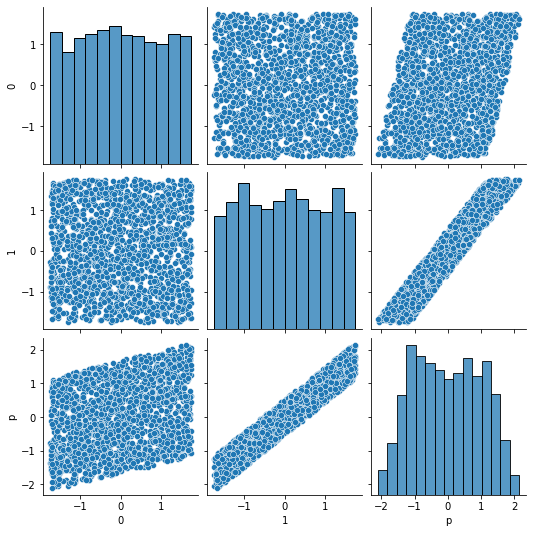

In [76]:
#CREATE TWO PAIRY PLOTS, ONE FOR TRAINING A

## TRAINING DATA 
df=pd.DataFrame(x_train)


df["p"] = p_train

## The Pairplot
sns.pairplot(df)

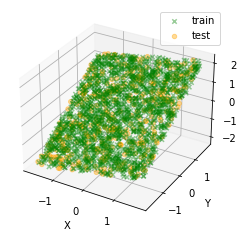

In [74]:
#PLOT IN 3D BOTH THE THE XYZ FOR TRAINING-SET AND PERDICTIONS ONLY IF x.shape[1]=2 (otherwise do nothing)
# NOTICE HOW THE UNITS CHANGES 

# INSERT CODE TO PLOT IN 3D BOTH THE THE TRAINING AND VALIDATION SET ONLY IF x.shape[1]=2 (otherwise do nothing)

if(x_train.shape[1]==2):
    # creating an empty canvas
    fig = plt.figure()
 
    # Creating an empty 3D axes of the plot
    ax = fig.add_subplot(projection='3d')

    # Labeling the X Axis
    ax.set_xlabel('X')
 
    # Labeling the Y-Axis
    ax.set_ylabel('Y')
 
    # Labeling the Z-Axis
    ax.set_zlabel('Z')

    # Creating a 2D data Scatter plot for the
    # on a 3D axis figure
    #ax.scatter(x.reshape(N,), y.reshape(N,), c='b')

    ##creating train and test dfs to plot

    train_df = pd.DataFrame(x_train)
    test_df = pd.DataFrame(x_test)

    ax.scatter(train_df[0], train_df[1],p_train, color = 'green', alpha = 0.4 ,label = "train", marker = 'x')

    ax.scatter(test_df[0], test_df[1],p_test, color = 'orange', alpha = 0.4 ,label = "test")

    plt.legend(loc="upper right")
 
    # 3D plot
    plt.show()
    
else :
    print("not valid number of columns")